# Лабораторна робота 1 — Дослідження даних з NumPy, Pandas та scikit-learn

**Набір даних:** `kc_house_data.csv`  
**Дозволені бібліотеки:** NumPy, Pandas, Matplotlib, scikit-learn (усі модулі)

## Налаштування — встановлення залежностей та імпорт

Запустіть комірку нижче один раз, щоб переконатись, що всі необхідні пакети встановлені.

In [ ]:
from google.colab import drive
import sys
drive.mount('/content/drive')
sys.path.append('/content/drive/MyDrive/MTAD_Labs/Lab1')

Mounted at /content/drive


In [ ]:
# Встановлення залежностей (можна запускати повторно)
import sys
!{sys.executable} -m pip install numpy pandas matplotlib scikit-learn --quiet


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)


---
## Завдання 1 — Розминка з NumPy

**а)** Створіть масив NumPy з 10 000 значень, що підпорядковані нормальному розподілу N(0, 1). Обчисліть середнє, стандартне відхилення, мінімум і максимум за допомогою функцій NumPy — **без Python-циклів**.

**б)** Підрахуйте, скільки значень виходять за межі ±2 стандартних відхилення, використовуючи логічну індексацію. Яка це відсоткова частка? Порівняйте з теоретичним значенням ≈4,55 %.

In [ ]:
# Завдання 1а — створіть масив і обчисліть статистику
data = np.random.normal(0, 1, 10000)

mean_val = np.mean(data)
std_val = np.std(data)
min_val = np.min(data)
max_val = np.max(data)

print(f"Середнє значення: {mean_val:.4f}")
print(f"Стандартне відхилення: {std_val:.4f}")
print(f"Мінімальне значення: {min_val:.4f}")
print(f"Максимальне значення: {max_val:.4f}")

Середнє значення: 0.0098
Стандартне відхилення: 1.0018
Мінімальне значення: -4.3422
Максимальне значення: 4.0241


In [ ]:
# Завдання 1б — підрахуйте викиди за допомогою логічної індексації
outliers_mask = (data < -2 * std_val) | (data > 2 * std_val)
outliers_count = np.sum(outliers_mask)

percentage = (outliers_count / len(data)) * 100

print(f"Кількість значень поза межами ±2σ: {outliers_count}")
print(f"Відсоткова частка: {percentage:.2f}%")
print(f"Очікуване теоретичне значення: ≈4.55%")

Кількість значень поза межами ±2σ: 426
Відсоткова частка: 4.26%
Очікуване теоретичне значення: ≈4.55%


**Ваша відповідь (б):** Отриманий результат 4.26% дуже близький до теоретичного значення 4.55%. Невелика розбіжність є цілком природною для випадкової вибірки з 10 000 елементів, що підтверджує відповідність даних нормальному розподілу.

---
## Завдання 2 — Завантаження та огляд набору даних

Завантажте `kc_house_data.csv` у Pandas DataFrame та дайте відповідь на питання нижче, написавши код:

1. Скільки рядків і стовпців у наборі даних?
2. Які мінімум, максимум, середнє та медіана цін на будинки?
3. Скільки унікальних поштових індексів є у наборі даних? Який поштовий індекс має найбільше оголошень?

In [ ]:
# Завантаження набору даних
sales = pd.read_csv('/content/drive/MyDrive/MTAD_Labs/Lab1/kc_house_data.csv')
sales.head()


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
# 2-і) Скільки рядків і стовпців?
rows, cols = sales.shape
print(f"У наборі даних {rows} рядків та {cols} стовпців.")

У наборі даних 21613 рядків та 21 стовпців.


In [ ]:
# 2-іі) Мінімум, максимум, середнє та медіана ціни
min_p = sales['price'].min()
max_p = sales['price'].max()
mean_p = sales['price'].mean()
median_p = sales['price'].median()

print(f"Мінімальна ціна: ${min_p:,.2f}")
print(f"Максимальна ціна: ${max_p:,.2f}")
print(f"Середня ціна: ${mean_p:,.2f}")
print(f"Медіанна ціна: ${median_p:,.2f}")

Мінімальна ціна: $75,000.00
Максимальна ціна: $7,700,000.00
Середня ціна: $540,088.14
Медіанна ціна: $450,000.00


In [ ]:
# 2-ііі) Кількість унікальних поштових індексів; індекс з найбільшою кількістю оголошень
unique_zipcodes = sales['zipcode'].nunique()

zip_counts = sales['zipcode'].value_counts()
top_zipcode = zip_counts.idxmax()
top_zipcode_count = zip_counts.max()

print(f"Унікальних поштових індексів: {unique_zipcodes}")
print(f"Найбільше оголошень ({top_zipcode_count}) має індекс: {top_zipcode}")

Унікальних поштових індексів: 70
Найбільше оголошень (602) має індекс: 98103


---
## Завдання 3 — Візуалізація даних

Створіть **два графіки поруч**:

- **Лівий:** гістограма `price` (50 інтервалів, логарифмічна шкала по осі X).
- **Правий:** діаграма розсіювання `sqft_living` vs `price`, де кольором точок позначено `bedrooms`. Додайте підписи осей і colorbar.

Одним реченням для кожного графіка опишіть, що ви спостерігаєте.

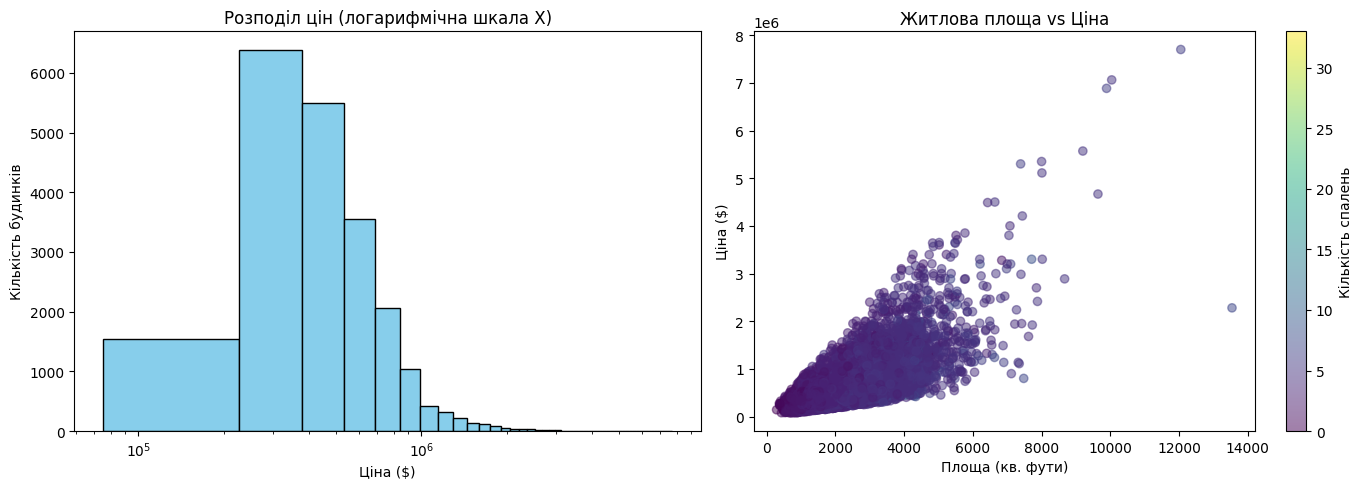

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Завдання 3 — лівий графік: гістограма ціни
axes[0].hist(sales['price'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_xscale('log')  # Логарифмічна шкала для X
axes[0].set_title('Розподіл цін (логарифмічна шкала X)')
axes[0].set_xlabel('Ціна ($)')
axes[0].set_ylabel('Кількість будинків')

# Завдання 3 — правий графік: діаграма розсіювання sqft_living vs price
scatter = axes[1].scatter(sales['sqft_living'], sales['price'], c=sales['bedrooms'], cmap='viridis', alpha=0.5)
axes[1].set_title('Житлова площа vs Ціна')
axes[1].set_xlabel('Площа (кв. фути)')
axes[1].set_ylabel('Ціна ($)')

fig.colorbar(scatter, ax=axes[1], label='Кількість спалень')

plt.tight_layout()
plt.show()


**Спостереження (лівий графік):** Розподіл цін має правобічну асиметрію, де основна маса будинків зосереджена в діапазоні від 300 до 600 тисяч доларів, а логарифмічна шкала дозволяє побачити поодинокі елітні об'єкти вартістю в кілька мільйонів.

**Спостереження (правий графік):** Між площею та ціною спостерігається чітка позитивна лінійна залежність, при цьому будинки з більшою площею зазвичай мають більше спалень, хоча в даних присутній аномальний об'єкт із екстремально великою кількістю кімнат.

---
## Завдання 4 — Навчання та оцінка регресійної моделі

Розбийте дані 80/20 (`random_state=42`). Навчіть `LinearRegression` з scikit-learn для передбачення `price` за єдиною ознакою `sqft_living`.

1. Вкажіть вільний член (intercept) та коефіцієнт для `sqft_living`.
2. Обчисліть MSE і RMSE на тестовій вибірці.
3. Яка передбачувана ціна будинку площею 2 500 кв. футів?

In [ ]:
# Поділ на навчальну та тестову вибірки
train_data, test_data = train_test_split(sales, test_size=0.2, random_state=42)


In [ ]:
# Завдання 4 — навчіть модель, вкажіть ваги, обчисліть MSE/RMSE, передбачте ціну для 2500 кв. фут.
X_train = train_data[['sqft_living']]
y_train = train_data['price']

X_test = test_data[['sqft_living']]
y_test = test_data['price']

model_1 = LinearRegression()
model_1.fit(X_train, y_train)

print(f"Вільний член (intercept): {model_1.intercept_:.2f}")
print(f"Коефіцієнт для sqft_living: {model_1.coef_[0]:.2f}")

y_pred = model_1.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

predicted_price = model_1.predict(pd.DataFrame([[2500]], columns=['sqft_living']))
print(f"Передбачувана ціна будинку (2500 кв. фут): ${predicted_price[0]:,.2f}")

Вільний член (intercept): -41999.19
Коефіцієнт для sqft_living: 279.55
MSE: 76484977061.78
RMSE: 276559.17
Передбачувана ціна будинку (2500 кв. фут): $656,887.76


---
## Завдання 5 — Порівняння двох моделей

Навчіть другу `LinearRegression` з ознаками: `sqft_living`, `bedrooms`, `bathrooms`, `yr_built`. Порівняйте RMSE на тестовій вибірці між Моделлю 1 та Моделлю 2. Яке значення нижче? Коротко поясніть чому.

In [ ]:
# Завдання 5 — модель з чотирма ознаками та порівняння RMSE
features = ['sqft_living', 'bedrooms', 'bathrooms', 'yr_built']

X_train_2 = train_data[features]
X_test_2 = test_data[features]

model_2 = LinearRegression()
model_2.fit(X_train_2, y_train)

y_pred_2 = model_2.predict(X_test_2)

rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred_2))

print(f"RMSE Моделі 1 (тільки площа): {rmse:.2f}")
print(f"RMSE Моделі 2 (4 ознаки): {rmse_2:.2f}")

if rmse_2 < rmse:
    print("\nМодель 2 показала кращий результат (нижчий RMSE).")
else:
    print("\nМодель 1 виявилася кращою.")

RMSE Моделі 1 (тільки площа): 276559.17
RMSE Моделі 2 (4 ознаки): 262985.98

Модель 2 показала кращий результат (нижчий RMSE).


**Відповідь:** Модель 2 показала нижчий показник RMSE (262,985.98 проти 276,559.17), що свідчить про вищу точність прогнозів. Це пояснюється тим, що ціна нерухомості залежить не лише від площі, а й від функціональності (кількість спалень та ванних кімнат) та стану будівлі (рік побудови). Додавання цих релевантних ознак дозволило алгоритму краще врахувати багатогранність ринку нерухомості.